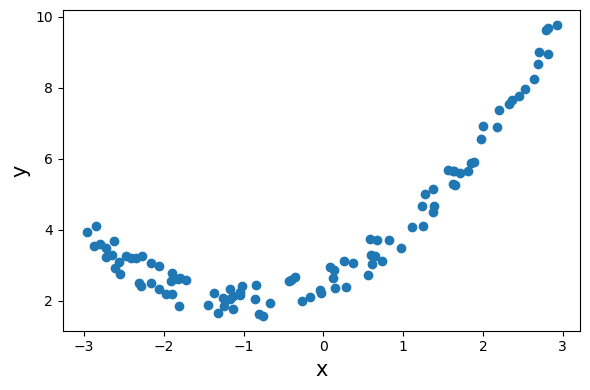

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터 생성
np.random.seed(42)
m = 100
x = 6 * np.random.rand(m,1) - 3
y=  0.5 * x**2 + x + 2 + np.random.rand(m,1)

# 데이터 분포
fig, ax = plt.subplots(figsize=(6,4))

ax.scatter(x,y)
ax.set_xlabel('x',fontsize=15)
ax.set_ylabel('y',fontsize=15)
plt.tight_layout()
plt.show()


In [4]:
# 선형 모델 적용
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x,y)

test_x = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)

# 예측
pred_y = model.predict(test_x)

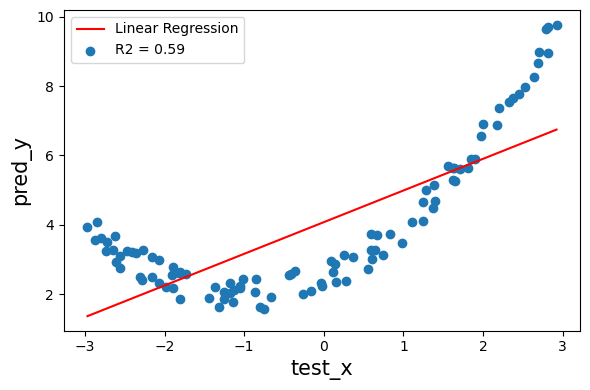

In [5]:
# 시각화

fig, ax = plt.subplots(figsize=(6,4))

ax.plot(test_x, pred_y, color='red')
ax.scatter(x,y)
ax.set_xlabel('test_x',fontsize=15)
ax.set_ylabel('pred_y',fontsize=15)
plt.legend(['Linear Regression', f'R2 = {model.score(x,y):.2f}'])
plt.tight_layout()
plt.show()

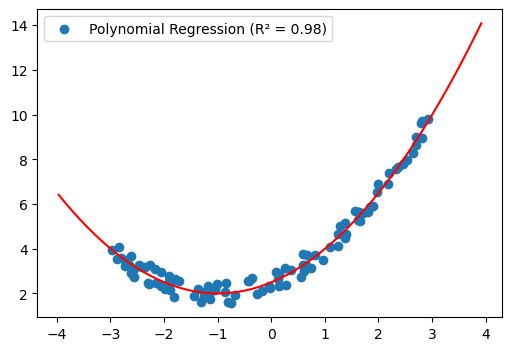

In [6]:
# 다항 회귀 모델 적용 / 시각화

p_x = np.hstack([x**2, x])
new_x = np.linspace(x.min()-1, x.max()+1, 100).reshape(-1,1)
lin_reg = LinearRegression()
lin_reg.fit(p_x,y)
y_pred = lin_reg.predict(np.hstack([new_x**2, new_x]))
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(x,y)
ax.plot(new_x, y_pred, color='red')
plt.legend([f'Polynomial Regression (R² = {lin_reg.score(p_x,y):.2f})'])
plt.show()

c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


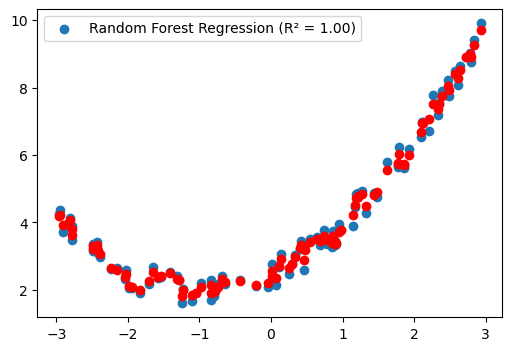

In [7]:
# 랜덤 포레스트 회귀 모델 적용 / 시각화

x = 6 * np.random.rand(m,1) - 3
y = 0.5 * x**2 + x + 2 + np.random.rand(m,1)

from sklearn.ensemble import RandomForestRegressor
random_model = RandomForestRegressor(n_estimators=100, random_state=42)
random_model.fit(x,y)

y_pred = random_model.predict(x)

fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(x,y)
ax.scatter(x, y_pred, color='red')
plt.legend([f'Random Forest Regression (R² = {random_model.score(x,y):.2f})'])
plt.show()

c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


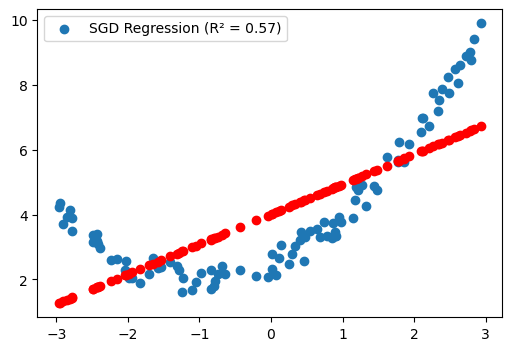

In [8]:
# 확률적 경사 하강법 모델 / 시각화
from sklearn.linear_model import SGDRegressor

sgd_model = SGDRegressor(max_iter=1000, random_state=42)
sgd_model.fit(x,y)
y_pred = sgd_model.predict(x)

fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(x,y)
ax.scatter(x, y_pred, color='red')
plt.legend([f'SGD Regression (R² = {sgd_model.score(x,y):.2f})'])
plt.show()


c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


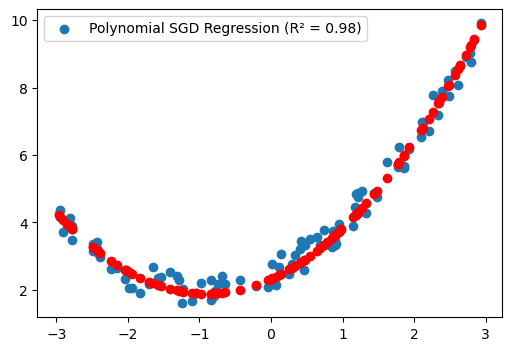

In [9]:
# 데이터 분포 직선변환
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
x_poly = poly.fit_transform(x)

sgd_model.fit(x_poly, y)
y_pred = sgd_model.predict(x_poly)

fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(x,y)
ax.scatter(x, y_pred, color='red')
plt.legend([f'Polynomial SGD Regression (R² = {sgd_model.score(x_poly,y):.2f})'])
plt.show()

In [10]:
# 과적합 (과소적합 과대적합)
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
np.random.seed(42)

# 샘플 수 적게
n_samples = 20
# feature 수 많게 -> 과적합 유도
n_features = 100 # 컬럼수 또는 x의 수

x = np.random.randn(n_samples, n_features)
true_coef = np.zeros(n_features)  # 처음에는 모든 feature가 중요하지 않다고 가정
# 일부 feature만 중요하다고 가정
true_coef[:5] = [10, -7, 5, 3, -2]  #실제로 앞의 5개만 y에 영향을 줌 / 나머지는 노이즈
# true_coef 각 변수들의 가중치

# 타겟을 생성 y = 10*1 + (-7)*2 + 5*3 + ...
y = x @ true_coef + np.random.rand(n_samples) * 5  # 정규분포 노이즈 추가

# 일반 선형회귀
# 모델 학습
# 결정계수

from sklearn.linear_model import LinearRegression

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(x_train, y_train)
print(f'R²: {model.score(x_train, y_train):.2f}')
model.predict(x_test)
print(f'R²: {model.score(x_test, y_test):.2f}')

R²: 1.00
R²: 0.40


In [11]:
# 모델이 노이즈까지 학습 
# 계수(가중치)가 비정상적으로 커짐 
# 규제로 해결 (Regularization)

# Ridge (L2)
    # loss = mse + sum(가중치**2)  --> 가중치 전체적으로 작게 만듬 , 모든 feature 유지, 안정적
    # 입력 스케일에 민감 -> 표준화 필요
# Lasso (L1)
    # loss = mse + sum(|가중치|)  --> 가중치 중 일부를 0으로 만듬, 자동 feature 선택 , 해석 용이

from sklearn.linear_model import Ridge, Lasso
ridge = Ridge(alpha=30)
ridge.fit(x_train, y_train)
print(f'Ridge R²: {ridge.score(x_train, y_train):.2f}')
print(f'Ridge R²: {ridge.score(x_test, y_test):.2f}')

lasso = Lasso(alpha=2)
lasso.fit(x_train, y_train)
print(f'Lasso R²: {lasso.score(x_train, y_train):.2f}')
print(f'Lasso R²: {lasso.score(x_test, y_test):.2f}')

Ridge R²: 0.94
Ridge R²: 0.38
Lasso R²: 0.94
Lasso R²: 0.55


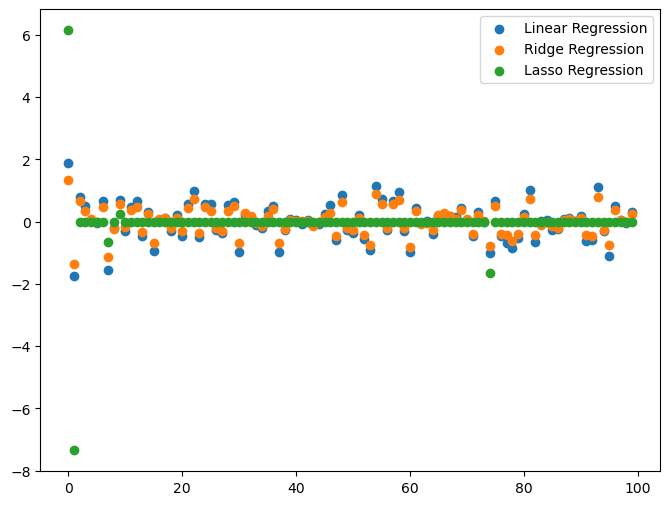

In [12]:
# 계수 비교
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(np.arange(len(model.coef_)), model.coef_, label='Linear Regression')
ax.scatter(np.arange(len(ridge.coef_)), ridge.coef_, label='Ridge Regression')
ax.scatter(np.arange(len(lasso.coef_)), lasso.coef_, label='Lasso Regression')

plt.legend()
plt.show()

# linear 계수 폭팔 (과적합) / ridge 전체적으로 작아짐 / lasso 일부 계수 0으로 만듬

In [13]:
# ridge와 lasso의 장점을 모두 활용한 elastic net
from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet(alpha=1, l1_ratio=0.5, random_state=42)  # l1_ratio=0.5 -> ridge와 lasso의 비율

In [14]:
# 조기종료
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDRegressor
import numpy as np
from copy import deepcopy

np.random.seed(42)

m = 100
x = 6 * np.random.rand(m,1) - 3
y = 0.5 * x**2 + x + 2 + np.random.rand(m,1)

x_train, y_train = x[:m//2], y[:m//2,0]
x_valid, y_valid = x[m//2:], y[m//2:,0]

pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=9, include_bias=False)),
    ('scale', StandardScaler())
])

x_train_prep = pipeline.fit_transform(x_train)
x_valid_prep = pipeline.transform(x_valid)  # ✅ 수정

sgd_reg = SGDRegressor(penalty=None, random_state=42)

low_epochs = 500
best_valid_rmse = float('inf')  # inf : 무한대

train_errors, val_errors = [], []

for epoch in range(low_epochs):
    sgd_reg.partial_fit(x_train_prep, y_train)

    # train error
    y_train_predict = sgd_reg.predict(x_train_prep)
    train_error = np.sqrt(mean_squared_error(y_train, y_train_predict))
    train_errors.append(train_error)

    # validation error
    y_valid_predict = sgd_reg.predict(x_valid_prep)
    val_error = np.sqrt(mean_squared_error(y_valid, y_valid_predict))
    val_errors.append(val_error)

    # 조기 종료 핵심
    if val_error < best_valid_rmse:
        best_valid_rmse = val_error
        best_model = deepcopy(sgd_reg)

# deepcopy : 객체를 완전히 독립적으로 복사 / 원본과 복사본이 서로 영향을 절대 주지 않음  --> 지금 상태 그대로 복제해서 따로 보관


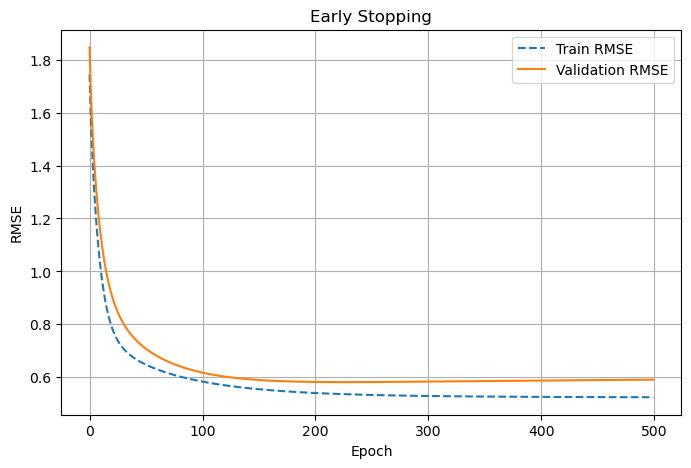

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(np.sqrt(train_errors), label="Train RMSE", linestyle='--')
plt.plot(np.sqrt(val_errors), label="Validation RMSE", linestyle='-')

plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Early Stopping")

plt.legend()
plt.grid(True)

plt.show()

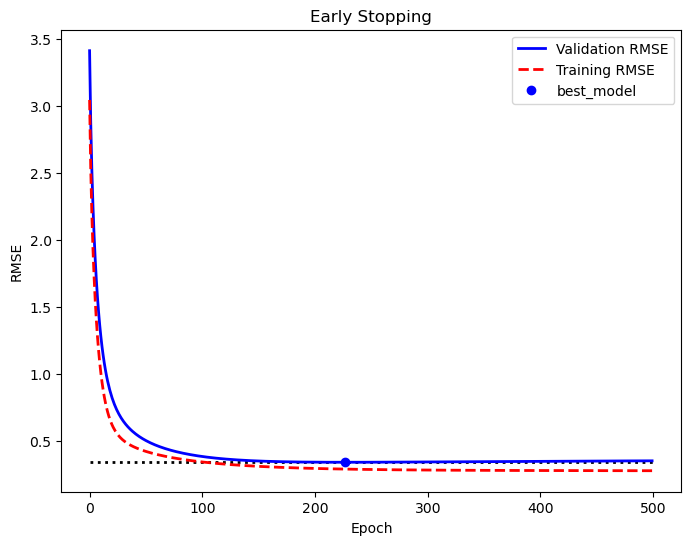

In [16]:
best_epoch = np.argmin(val_errors)
fig, ax = plt.subplots(figsize=(8,6))
ax.plot([0,low_epochs], [best_valid_rmse, best_valid_rmse], 'k:', linewidth=2)
ax.plot(val_errors, 'b-', linewidth=2, label="Validation RMSE")
ax.plot(train_errors, 'r--', linewidth=2, label="Training RMSE")
ax.plot(best_epoch, best_valid_rmse, 'bo', label='best_model')

plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Early Stopping")

plt.legend()
plt.show()

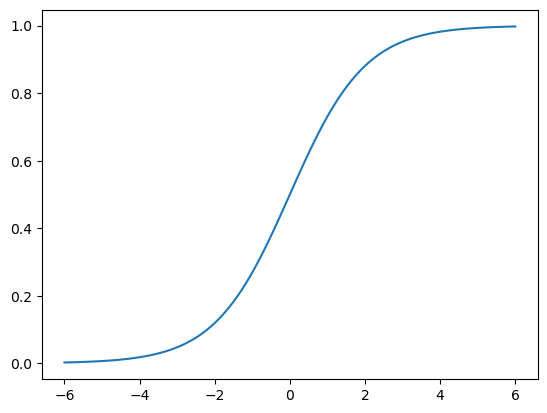

In [17]:
# 로지스틱회귀 -> 분류모델
import matplotlib.pyplot as plt

# 시그모이드
lim = 6
t = np.linspace(-lim, lim, 100)
sig = 1 / (1 + np.exp(-t))

plt.plot(t, sig)


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification

x, y = make_classification(
    n_samples=1000,
    n_features=20,
    # n_informative=   # 실제로 중요한 feature
    # n_redundant=     # informative 조합으로 만든 feature
    n_classes=2,
    random_state=42
)


In [19]:
logistic = LogisticRegression()
logistic.fit(x,y)
y_pred = logistic.predict(x[:5])
print(y_pred)
y_pred_proba = logistic.predict_proba(x[:5])
print(y_pred_proba)

[1 0 1 1 0]
[[0.01698676 0.98301324]
 [0.8231496  0.1768504 ]
 [0.05614544 0.94385456]
 [0.12982649 0.87017351]
 [0.71744582 0.28255418]]
